# Project 1: Data Analysis and Visualization. Analysis of Resumes from HeadHunter

In [10]:
# Import libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

## Problem Statement

The project addresses the challenge of processing and analyzing a large dataset of job seeker resumes from the HeadHunter platform to uncover patterns and dependencies in job seeker characteristics, such as age, work experience, education, and desired salary. The dataset contains complex, unstructured text features that require transformation and cleaning to enable meaningful analysis and visualization.

**Project Overview**

This project involves **exploratory data analysis (EDA)** and **visualization** of a dataset containing approximately **45,000 resumes from HeadHunter**. The focus is on transforming text data into structured features, cleaning the dataset of duplicates and outliers, and analyzing dependencies between features. Visualizations are used to identify trends and anomalies, providing insights into job seeker preferences and salary expectations.

**Business Task**

Develop a comprehensive analysis of job seeker resumes to identify key characteristics and preferences, enabling better alignment of recruitment strategies with market demands and improving the efficiency of talent acquisition processes.

**Technical Task**

As a Data Science specialist, perform the following:

Transform unstructured text features into structured categorical and numerical formats. Clean the dataset, Conduct EDA to explore distributions and dependencies, using visualizations and Pandas library to uncover patterns in job seeker data.

**Main Objectives:**

* Effective Data Preprocessing: Transform and clean the dataset to ensure data quality for analysis, addressing missing values, anomalies, and inconsistencies.

* Comprehensive Data Exploration: Analyze the structure and distributions of resume features to understand job seeker demographics and preferences.

* Insightful Dependency Analysis: Identify and visualize relationships between key features (e.g., salary vs. education, experience vs. age) to provide actionable recruitment insights.

## 1. Data Structure Exploration

Let's get acquainted with the data and explore their structure. Read the data using the Pandas library, examine the data for missing values, and check statistical metrics.

In [ ]:
# Load the data

hh_data = pd.read_csv('data/dst-3.0_16_1_hh_database.csv', sep=';')
hh_data.head(3)

In [42]:
# Display the first (or last) few rows of the table to ensure that your data is not corrupted. Familiarize yourself with the features and their structure

hh_data.tail(3)

,"Пол, возраст",ЗП,Ищет работу на должность:,"Город, переезд, командировки",Занятость,График,Опыт работы,Последнее/нынешнее место работы,Последняя/нынешняя должность,Образование и ВУЗ,Обновление резюме,Авто
44741,"Женщина , 48 лет , родилась 26 декабря 1970",40000 руб.,"Аналитик данных, Математик","Челябинск , готова к переезду , готова к редки...",полная занятость,"полный день, удаленная работа",Опыт работы 21 год 5 месяцев Январь 1998 — по...,"ОАО «ЧМК», Исследовательско-Технологический Це...",Начальник группы аналитики,Высшее образование 2000 Южно-Уральский госуда...,09.04.2019 05:07,Не указано
44742,"Мужчина , 24 года , родился 6 октября 1994",20000 руб.,Контент-менеджер,"Тамбов , не готов к переезду , не готов к кома...","частичная занятость, полная занятость",удаленная работа,Опыт работы 3 года 10 месяцев Контент-менедже...,IQ-Maxima,Менеджер проектов,Высшее образование 2015 Тамбовский государств...,26.04.2019 14:25,Имеется собственный автомобиль
44743,"Мужчина , 38 лет , родился 25 апреля 1980",120000 руб.,Руководитель проекта,"Москва , не готов к переезду , не готов к кома...",полная занятость,полный день,Опыт работы 15 лет 10 месяцев Руководитель пр...,ПАО ГК ТНС энерго,Руководитель отдела технической поддержки,Высшее образование 1997 Южно-Российский госуд...,05.07.2018 20:15,Не указано


In [43]:
# Display basic information about the number of non-empty values in columns and their types in the table.

hh_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   Пол, возраст                     44744 non-null  object
 1   ЗП                               44744 non-null  object
 2   Ищет работу на должность:        44744 non-null  object
 3   Город, переезд, командировки     44744 non-null  object
 4   Занятость                        44744 non-null  object
 5   График                           44744 non-null  object
 6   Опыт работы                      44576 non-null  object
 7   Последнее/нынешнее место работы  44743 non-null  object
 8   Последняя/нынешняя должность     44742 non-null  object
 9   Образование и ВУЗ                44744 non-null  object
 10  Обновление резюме                44744 non-null  object
 11  Авто                             44744 non-null  object
dtypes: object(12)
memory usage: 4.1+

We have missing data in the features `Опыт работы` (Work Experience), `Последнее/нынешнее место работы` (Last/Current Workplace), and `Последняя/нынешняя должность` (Last/Current Positio)n. All features are categorical before transformations.

In [44]:
# Display basic statistical information about the columns, currently only for "categorical" ones

hh_data.describe().T

,count,unique,top,freq
"Пол, возраст",44744,16003,"Мужчина , 32 года , родился 17 сентября 1986",18
ЗП,44744,690,50000 руб.,4064
Ищет работу на должность:,44744,14929,Системный администратор,3099
"Город, переезд, командировки",44744,10063,"Москва , не готов к переезду , не готов к кома...",1261
Занятость,44744,38,полная занятость,30026
График,44744,47,полный день,22727
Опыт работы,44576,44413,Опыт работы 10 лет 8 месяцев Апрель 2018 — по...,3
Последнее/нынешнее место работы,44743,30214,Индивидуальное предпринимательство / частная п...,935
Последняя/нынешняя должность,44742,16927,Системный администратор,2062
Образование и ВУЗ,44744,40148,Высшее образование 1987 Военный инженерный Кра...,4


### Intermediate Conclusions After Data Familiarization

* Our dataset contains nearly 45,000 records.

* The most common job seekers are those looking for system administrator roles.

* Full-time employment is sought in two-thirds of the cases.

* Job seekers consider nearly 15,000 unique positions.

* Approximately 50% of job seekers are looking for full-day work.


## 2. Data Transformation

Let's start with something simple - **`Образование и ВУЗ`** (the "Education and University") feature. Its current format is: **`Уровень образования год выпуска ВУЗ специальность...`** (<Education level, year of graduation, university, specialty...>). For example:
* `Высшее образование 2016 Московский авиационный институт (национальный исследовательский университет)` (Higher education 2016 Moscow Aviation Institute (National Research University));
* `Неоконченное высшее образование 2000  Балтийская государственная академия рыбопромыслового флота` (Incomplete higher education 2000 Baltic State Academy of the Fishing Fleet);

We are only interested in the education level.

Create a new feature **`Образование`** ("Education") using a transformation function, which should have 4 categories: `высшее` ("higher"), `неоконченное высшее` ("incomplete higher"), `среднее специальное` ("secondary special") and `среднее` ("secondary").
Transform the data and remove the original column.

In [45]:
# Transform education data

# Create a dictionary defining education categories

education_level = {'высшее' : 'Высшее образование',
                   'неоконченное высшее' : 'Неоконченное высшее',
                   'среднее специальное' : 'Среднее специальное',
                   'среднее' : 'Среднее'
}

# Create a function that transforms the data into our categories

def find_education_level(x):
    """Determines the education level based on the description text.

    Args:
    x (str): String containing the description of the education level and university

    Returns:
    str: Key from the education_level dictionary corresponding to the found education level
    """
    
    x_splited = x.split()
    x_education = " ".join(x_splited[:2])
    for key, level in education_level.items():
        if level in x_education:
            return key

# Apply the function and remove the original column with the data

hh_data['Образование'] = hh_data['Образование и ВУЗ'].apply(find_education_level)
hh_data = hh_data.drop(['Образование и ВУЗ'], axis=1)


Now we are interested in the `Пол`, `возраст` (the "Gender, Age") column. It is currently presented in the format <Пол , возраст , дата рождения> (<Gender, age, date of birth>).

For example:

* `Мужчина , 39 лет , родился 27 ноября 1979` (Male, 39 years old, born November 27, 1979)

* `Женщина , 21 год , родилась 13 января 2000` (Female, 21 years old, born January 13, 2000)

We need to extract each parameter into a separate column.
Create two new features `Пол` ("Gender") and `Возраст` ("Age"). It is important to consider:

The `Пол` ("Gender") feature should have 2 unique string values: `М ("M")` - male, `Ж ("F")` - female.
The `Возраст` ("Age") feature should be represented as integers.

Perform the transformation and remove the `Пол`, `возраст` ("Gender, Age") feature from the table.

In [46]:
# Transform data for gender and age features

# Create a function to extract gender information

def find_gender(x):
    """Determines gender based on the description text

    Args:
    x (str): String containing the description of gender and age

    Returns:
    str: Key from the dictionary containing the gender feature of the job seeker
    """ 
    gender_dict = {'М' : 'мужчина', 'Ж' : 'женщина'}
    x_splited = x.split(' , ')
    gender = x_splited[0].lower()
    for key, value in gender_dict.items():
        if gender == value:
            return key

# Create a function to extract age information

def find_age(x):
    """Determines age based on the description text

    Args:
    x (str): String containing the description of gender and age

    Returns:
    int: Cleaned age value of the job seeker
    """
    x_splited = x.split(',')
    age = x_splited[1].split()
    return int(age[0])

# Apply the functions and remove the original column with the data

hh_data['Пол'] = hh_data['Пол, возраст'].apply(find_gender)
hh_data['Возраст'] = hh_data['Пол, возраст'].apply(find_age)

hh_data = hh_data.drop(['Пол, возраст'], axis=1)

The next step is to transform the `Опыт работы` (the "Work Experience") feature. Its current format is: `<Опыт работы: n лет m месяцев, периоды работы в различных компаниях…>` (<Work experience: n years m months, periods of work in various companies…>).

**From the column, we need to extract the total work experience of the job seeker in months**; the new feature will be called `Опыт работы (месяц)` ("Work Experience (months)").

First, let's discuss the conditions for solving the task:

* Firstly, **this feature has missing values**. Let's agree that if we encounter a missing value, we leave it as is (**the transformation function returns NaN**).
* Secondly, this feature **has hidden missing values**. For some job seekers, the column contains the value `Не указано` ("Not specified"). These will also be designated as NaN (**the transformation function returns NaN**).
* Thirdly, **we are not interested in the information described after the work experience** (periods of work in various companies).
* Fourthly, we have a problem: **work experience may be presented only in years or only in months**. For example, you may encounter the following variants:
    - `Опыт работы 3 года 2 месяца…` (Work experience 3 years 2 months…)
    - `Опыт работы 4 года…` (Work experience 4 years…)
    - `Опыт работы 11 месяцев…` (Work experience 11 months…)

As a result of the transformation, you should obtain a column containing **information about how many months the job seeker has worked**.

In [47]:
# Transform work experience data

# Create a function to extract work experience information in months

def find_expirience(x):
    """Determines work experience in months based on the description text

    Args:
    x (str): String containing work experience

    Returns:
    int: Work experience value in months
    """
    
    years_list = ['год', 'года', 'лет']
    months_list = ['месяца', 'месяц', 'месяцев']
    
    year = 0
    month = 0

    if pd.isna(x) or x == "Не указано":
        return np.nan
    else:
        x_splited = x.split()[:6]
        for i in range(len(x_splited)):
            if x_splited[i] in years_list:
                year = x_splited[i-1]
            elif x_splited[i] in months_list:
                month = x_splited[i-1]

        total_experience = int(year) * 12 + int(month)
        return total_experience

# Apply the function and remove the original column with the data 
         
hh_data['Опыт работы (месяц)'] = hh_data['Опыт работы'].apply(find_expirience)
hh_data = hh_data.drop(['Опыт работы'], axis=1)

The next feature in line is `Город, переезд, командировки` (the "City, Relocation, Business Trips"). The information in it is presented as follows: `<Город , (метро) , готовность к переезду (города для переезда) , готовность к командировкам>` (<City, (metro), readiness for relocation (cities for relocation), readiness for business trips>). The parameters in parentheses are optional. For example, you may encounter the following variants:

* `Москва , не готов к переезду , готов к командировкам` (Moscow, not ready for relocation, ready for business trips)
* `Москва , м. Беломорская , не готов к переезду, не готов к командировкам` (Moscow, Belomorskaya metro, not ready for relocation, not ready for business trips)
* `Воронеж , готов к переезду (Сочи, Москва, Санкт-Петербург) , готов к командировкам` (Voronezh, ready for relocation (Sochi, Moscow, Saint Petersburg), ready for business trips)

Create separate features `Город` ("City"), `Готовность к переезду` ("Readiness for Relocation"), `Готовность к командировкам` ("Readiness for Business Trips"). It is important to consider:

The `Город` ("City") feature should contain only 4 categories: `Москва` ("Moscow"), `Санкт-Петербург` ("Saint Petersburg"), and `город-миллионник` ("million-plus city") (their list is below); others should be designated as `другие` ("other").

**List of million-plus cities:**

<code>million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']</code>

Information about the metro station near which the job seeker lives **is not of interest**.

The `Готовность к переезду` ("Readiness for Relocation") feature should have two possible variants: True or False. Note that there may be several descriptions of readiness for relocation in the `Город, переезд, командировки` ("City, Relocation, Business Trips") feature. For example:

… , `готов к переезду` (ready for relocation) , …
… , `не готова к переезду` (not ready for relocation) , …
… , `готова к переезду (Москва, Санкт-Петербург, Ростов-на-Дону)` (ready for relocation (Moscow, Saint Petersburg, Rostov-on-Don))
… , `хочу переехать (США)` (want to relocate (USA)) , …

**We are only interested in the fact of the possibility or desire to relocate**.

The `Готовность к командировкам` ("Readiness for Business Trips") feature should have two possible variants: True or False. Note that there may be several descriptions of readiness for business trips in the `Город, переезд, командировки` ("City, Relocation, Business Trips") feature. For example:

… , `готов к командировкам` (ready for business trips) , …
… , `готова к редким командировкам` (ready for occasional business trips) , …
… , `не готов к командировкам` (not ready for business trips) , …

**We are only interested in the fact of readiness for business trips.**

Another important fact: during data export, **information about readiness for business trips was "lost" for some job seekers**. Let's assume **by default that such job seekers are not ready for business trips**.

Perform the transformations and remove the `Город, переезд, командировки` ("City, Relocation, Business Trips") column from the table.

In [48]:
# Transform data about the job seeker's place of residence, readiness for relocation, and business trips

# Create a list of million-plus cities for further categorization

million_cities = ['Новосибирск', 'Екатеринбург','Нижний Новгород','Казань', 'Челябинск','Омск', 'Самара', 'Ростов-на-Дону', 'Уфа', 'Красноярск', 'Пермь', 'Воронеж','Волгоград']

# Create a function to create the City feature

def find_city(x):
    """Determines the city based on the description text

    Args:
    x (str): String containing information about the city

    Returns:
    str: Cleaned string with the City feature
    """
    
    town = x.split(' , ')[0]
    if 'Москва' in town:
        cleaned_town = 'Москва' 
    elif 'Санкт-Петербург' in town:
        cleaned_town = 'Санкт-Петербург'
    elif town in million_cities:
        cleaned_town = 'город-миллионник'
    else:
        cleaned_town = 'другие'
    return cleaned_town

# Create a function to create the Readiness for Relocation feature

def find_movement_availability(x):
    """Determines Readiness for Relocation based on the description text

    Args:
    x (str): String containing information about Readiness for Relocation

    Returns:
    str: Cleaned string with the Readiness for Relocation feature
    """
    
    if ('не готов к переезду' in x) or ('не готова к переезду' in x):
        return False
    elif 'хочу' in x:
        return True
    else:
        return True
 
# Create a function to create the Readiness for Business Trips feature
    
def find_businesstrip_availability(x):
    """Determines Readiness for Business Trips based on the description text

    Args:
    x (str): String containing information about Readiness for Business Trips

    Returns:
    str: Cleaned string with the Readiness for Business Trips feature
    """
    
    if ('командировка' in x):
        if ('не готов к командировкам' in x) or ('не готова к командировкам' in x):
            return False
        else: 
            return True
    else:
        return False
    
# Apply the functions and remove the original column with the data    
 
hh_data['Город'] = hh_data['Город, переезд, командировки'].apply(find_city)   
hh_data['Готовность к переезду'] = hh_data['Город, переезд, командировки'].apply(find_movement_availability)
hh_data['Готовность к командировкам'] = hh_data['Город, переезд, командировки'].apply(find_businesstrip_availability)

hh_data = hh_data.drop(['Город, переезд, командировки'], axis=1)

Let's take a closer look at the `Занятость` ("Employment") and `График` ("Schedule") features. Currently, these features represent a set of desired employment categories (`полная занятость` ("full-time employment"), `частичная занятость` ("part-time employment"), `проектная работа` ("project work"), `волонтерство` ("volunteering"), `стажировка` ("internship")) and desired work schedule categories (`полный день` ("full day"), `сменный график` ("shift schedule"), `гибкий график` ("flexible schedule"), `удаленная работа` ("remote work"), `вахтовый метод` ("rotational work")).

On the hh.ru website, a job seeker can specify various combinations of these categories, for example:

* `полная занятость, частичная занятость` (full-time employment, part-time employment)
* `частичная занятость, проектная работа, волонтерство` (part-time employment, project work, volunteering)
* `полный день, удаленная работа` (full day, remote work)
* `вахтовый метод, гибкий график, удаленная работа, полная занятость` (rotational work, flexible schedule, remote work, full-time employment)

Such a feature format **has many different combinations**, hence many unique values, which hinders analysis.

Let's create indicator features for each category: if a category is present in the list of desired ones by the job seeker, then the column for that job seeker's row is set to `True`, otherwise - `False`.

In [49]:
# Transform data about the type of employment and desired work schedule of the job seeker

# Create a list of employment types for further column filling

employment_list = [
    'полная занятость',
    'частичная занятость',
    'проектная работа',
    'стажировка',
    'волонтерство'
]

# Create columns for employment types through a loop and fill them with boolean values 

for employment in employment_list:
    hh_data[employment] = hh_data['Занятость'].apply(lambda x: employment in x.split(', '))

# Create a list of schedule types for further column filling

schedule_list = [
    'полный день',
    'сменный график',
    'гибкий график',
    'удаленная работа',
    'вахтовый метод'
]

# Create columns for desired work schedules through a loop and fill them with boolean values

for schedule in schedule_list:
    hh_data[schedule] = hh_data['График'].apply(lambda x: schedule in x.split(', '))
 
# Remove the original column with the data 
   
hh_data = hh_data.drop(['Занятость', 'График'], axis=1)

Transform the expected `ЗП` ("Salary") feature and **convert it to a single currency**. We will use a second dataset with exchange rates for a specific date. 

Let's discuss a possible transformation algorithm:

* Convert the `Обновление резюме` ("Resume Update") feature from the resume table **to datetime format and extract the date from it**. Convert the date feature from the currency table to the same format.

* **Extract the desired salary amount and the currency name** in which it is denominated from the `ЗП` ("Salary") column. **Convert the currency name to the ISO standard** according to the table above.

* **Join the resume table with the currency table by the columns with the date and currency name**. **Fill the close value for the ruble with one 1** (the ruble's exchange rate to itself).
**Multiply the desired salary amount by the joined currency rate** (close) and **divide by the proportion** (pay attention to missing values after merging in these columns), and record the result in a new column `ЗП (руб)` ("Salary (RUB)").


In [50]:
# Transform data about the desired salary, converting foreign currencies to rubles

# Import an additional dataset with daily currency exchange rates, convert the date column to datetime format

exchange_data = pd.read_csv('data/ExchangeRates.csv', sep=',')
exchange_data['date'] = pd.to_datetime(exchange_data['date'], dayfirst=True).dt.date

# Convert the date column in the original dataset to the same datetime format

hh_data['Обновление резюме'] = pd.to_datetime(hh_data['Обновление резюме'], dayfirst=True).dt.date

# Create two additional features for the desired salary in the original dataset

hh_data['Сумма ЗП'] = hh_data['ЗП'].apply(lambda x: x.split()[0])
hh_data['Валюта'] = hh_data['ЗП'].apply(lambda x: x.split()[1])

# Create a function to standardize all currency types in the original dataset

def to_iso(cur):
    """Converts the Currency feature to ISO standard based on the description text

    Args:
    cur (str): Currency name in the data

    Returns:
    str: Currency data standardized to ISO
    """
    
    # Create a dictionary with currency data
    
    currency_dict = {
    'USD': 'USD', 'KZT': 'KZT',
    'грн': 'UAH', 'белруб': 'BYN',
    'EUR': 'EUR', 'KGS': 'KGS',
    'сум': 'UZS', 'AZN': 'AZN',
    'руб': 'RUB'
}
    currency = cur.split()[-1]
    currency = currency.replace('.', '')
    
    return currency_dict[currency]

# Apply the function and standardize the currency feature 
   
hh_data['Валюта'] = hh_data['ЗП'].apply(to_iso)

# Merge the datasets, joining the currency name, exchange rate date, rate, and proportion information to our main dataset

hh_data = hh_data.merge(
    exchange_data[['currency', 'date', 'proportion', 'close']],
    how='left',
    right_on=['date', 'currency'],
    left_on=['Обновление резюме', 'Валюта']
)

# Fill missing values for the RUB currency

rub_mask = hh_data['Валюта'] == 'RUB'

hh_data.loc[rub_mask, 'close'] = hh_data.loc[rub_mask, 'close'].fillna(1)
hh_data.loc[rub_mask, 'proportion'] = hh_data.loc[rub_mask, 'proportion'].fillna(1)

# Convert the salary amount feature to the integer data type and calculate the salary amount in rubles using the exchange rate data

hh_data['Сумма ЗП'] = hh_data['Сумма ЗП'].astype('int64')
hh_data['ЗП (руб)'] = (hh_data['Сумма ЗП'] * hh_data['close']) / hh_data['proportion']

# Remove unnecessary columns with data

hh_data = hh_data.drop(['ЗП', 'Сумма ЗП', 'Валюта', 'currency', 'date', 'proportion', 'close'], axis=1)

C:\Users\ademidov\AppData\Local\Temp\ipykernel_13848\1190497989.py:6: UserWarning:

Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.



## 3. Exploring Dependencies in Data

Post-build the distribution of the **`Возраст`** ("Age") feature. Describe the distribution by answering the following questions: 
* What is the mode of the distribution? 
* What are the boundary values of the feature? 
* In what approximate range does the age of most job seekers fall? 
* Are there any anomalies for the age feature, and which values would you consider anomalous?

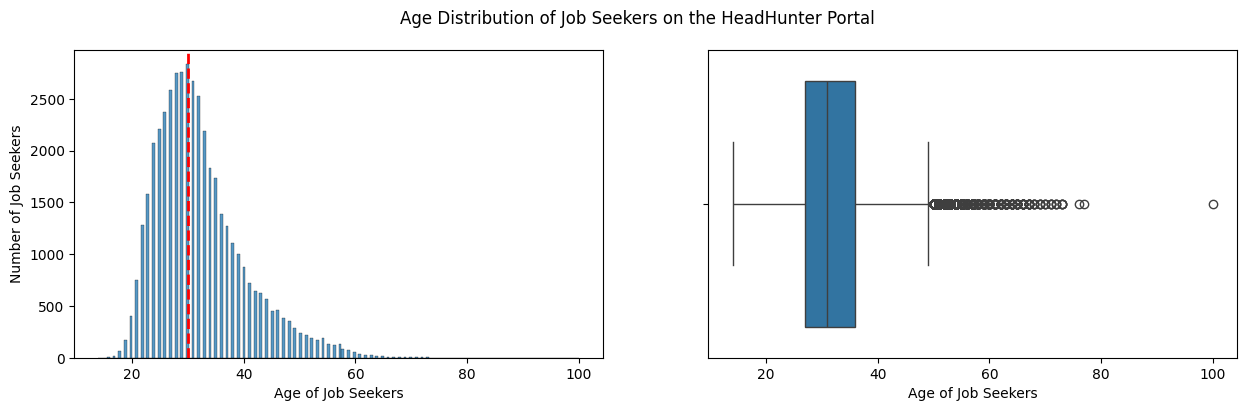

In [51]:
# Build the distribution of the "Age" feature. Use subplots and display a histogram and boxplot

age_mode = hh_data['Возраст'].mode().iloc[0]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,4))
histplot = sns.histplot(
    hh_data,
    x='Возраст',
    ax=axes[0] 
)
boxplot = sns.boxplot(
    hh_data,
    x='Возраст',
    ax=axes[1]
)

axes[0].axvline(age_mode, color='r',ls='--', lw=2)
fig.suptitle('Age Distribution of Job Seekers on the HeadHunter Portal', fontsize=12)  
histplot.set_ylabel('Number of Job Seekers')  
histplot.set_xlabel('Age of Job Seekers')  
boxplot.set_xlabel('Age of Job Seekers');

**The mode of the distribution is 30 years**, clearly visible from the peak in the histogram. The distribution resembles a lognormal one, with a long tail toward older ages. **The age of most job seekers falls in the range of approximately 25–38 years**, **with a median age slightly above 30 years**. The boxplot shows the presence of job seekers who have reached retirement age, which may require further analysis. Additionally, there is **one anomalous value > 100 years and several values around 80 years**, which, based on life logic, are likely errors.

Post-build the distribution of the **`Опыт работы (месяц)`** ("Work Experience (months)") feature. Describe this distribution by answering the following questions: 
* What is the mode of the distribution? 
* What are the boundary values of the feature? 
* In what approximate range does the work experience of most job seekers fall? 
* Are there any anomalies for the work experience feature, and which values would you consider anomalous?

Text(0.5, 0, 'Work Experience of Job Seekers')

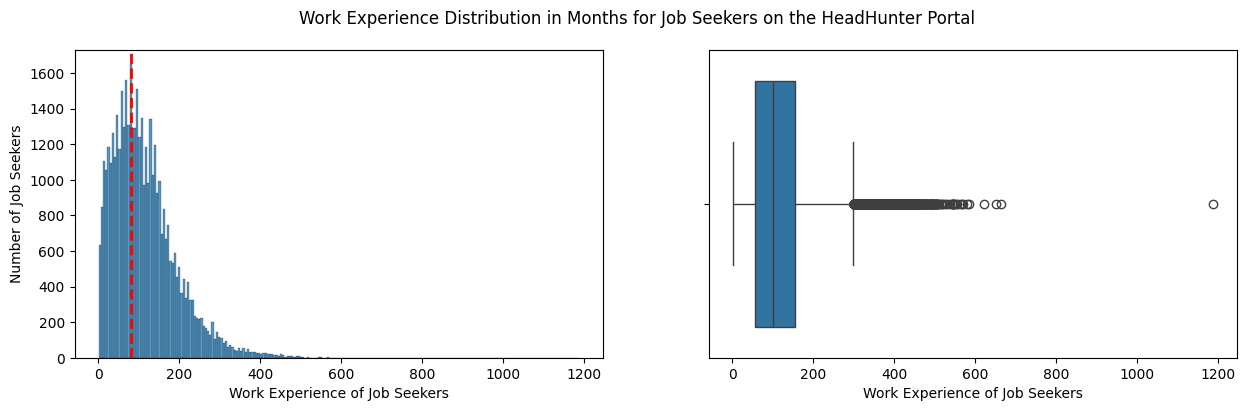

In [52]:
# Build the distribution of the "Work Experience (months) feature. Use subplots and display a histogram and boxplot

exp_mode = hh_data['Опыт работы (месяц)'].mode().iloc[0]

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,4))
histplot = sns.histplot(
    hh_data,
    x='Опыт работы (месяц)',
    ax=axes[0] 
)
boxplot = sns.boxplot(
    hh_data,
    x='Опыт работы (месяц)',
    ax=axes[1]
)

axes[0].axvline(exp_mode, color='r',ls='--', lw=2)
fig.suptitle('Work Experience Distribution in Months for Job Seekers on the HeadHunter Portal', fontsize=12)  
histplot.set_ylabel('Number of Job Seekers')  
histplot.set_xlabel('Work Experience of Job Seekers')  
boxplot.set_xlabel('Work Experience of Job Seekers')

Overall, work experience aligns with the age distribution of job seekers. As seen, **most job seekers have work experience ranging from 0 to approximately 160–180 months**. **The mode of the distribution is 81 months**. The distribution also resembles a lognormal one, with a tail toward larger values, which may be related to age. **The median work experience is around 100 months**. The boxplot shows **job seekers with work experience ranging from 300 to 600 months**, which requires further analysis and data verification. Additionally, we see **one value at 1188 months**, which is likely erroneous data.

Post-build the distribution of the **`ЗП (руб)`** ("Salary (RUB)") feature. Describe this distribution by answering the following questions: 
* What are the boundary values of the feature? 
* In what approximate range does the desired salary of most job seekers fall? 
* Are there any anomalies for the salary feature?


Text(0.5, 0, 'Desired Salary in Rubles')

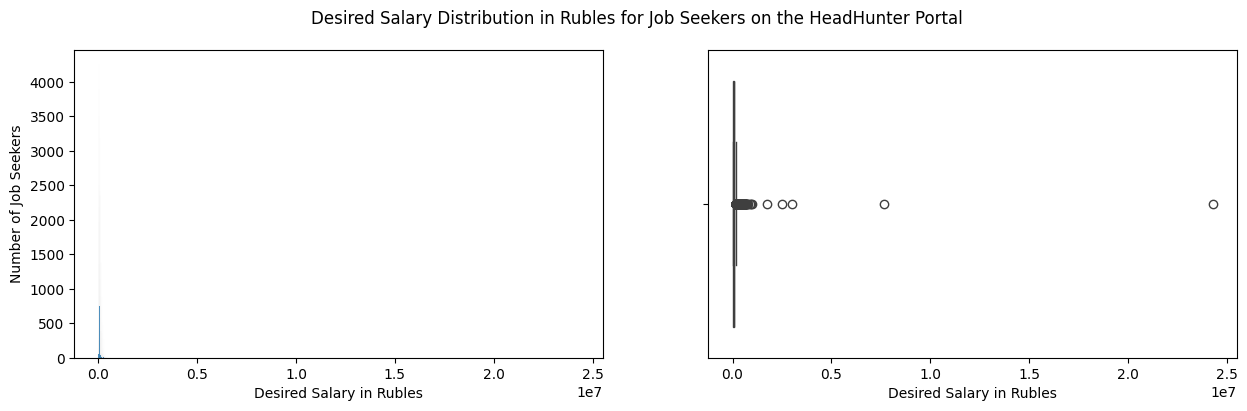

In [53]:
# Build the distribution of the "Salary (RUB)" feature. Use subplots and display a histogram and boxplot

fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15,4))
histplot = sns.histplot(
    hh_data,
    x='ЗП (руб)',
    ax=axes[0]
)
boxplot = sns.boxplot(
    hh_data,
    x='ЗП (руб)',
    ax=axes[1]
)

fig.suptitle('Desired Salary Distribution in Rubles for Job Seekers on the HeadHunter Portal', fontsize=12)  
histplot.set_ylabel('Number of Job Seekers')  
histplot.set_xlabel('Desired Salary in Rubles')  
boxplot.set_xlabel('Desired Salary in Rubles')

**Almost nothing is visible in this distribution** due to anomalously high values that stretch the distribution. **A maximum salary of approximately 25 million rubles is observed, along with one value around 8 million rubles**. These values need to be removed from our dataset in the future. However, we can see in the distribution that **the majority of job seekers indicate a desired salary of up to 100,000 rubles**, which appears close to 0 on our graph.

Post-build a chart showing the dependence of the **median** desired salary on the level of education. Use data from resumes where the desired salary is less than 1 million rubles for the chart. Make conclusions based on the presented chart: 
* Which education levels have the highest and lowest desired salary levels? 
* Do you think the education level feature is important for predicting salary?

In [ ]:
# Build a chart of the dependence of the median desired salary on the level of education. Use a bar chart from the Plotly Express library

edu_salary_data = hh_data[hh_data['ЗП (руб)'] < 1000000].groupby('Образование', as_index=False)['ЗП (руб)'].median()

fig = px.bar(
    edu_salary_data,
    x='Образование',
    y='ЗП (руб)',
    color='Образование',
    text = 'ЗП (руб)',
    orientation='v',
    height=500, 
    width=1000, 
    title='Median Desired Salary in Rubles for Job Seekers by Education Level',
    labels={
        'Образование':'Education Level',
        'ЗП (руб)': 'Salary (Rub)',
        'Образование' :'Education Level'
    }
)

fig.show();

#fig.write_html("plotly/education_salary.html")


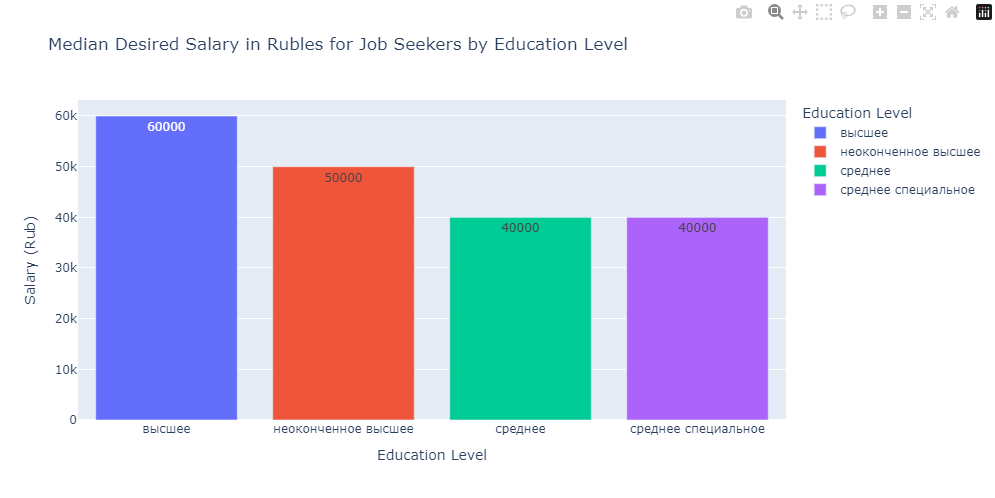

From the obtained chart, we can conclude that **specialists with completed higher education aim for the highest salaries**. Next are specialists with incomplete higher education. **There is no difference in the median desired salary levels between specialists with secondary and secondary special education**. Regarding whether the **`Образование`** ("Education") feature is necessary for salary prediction, **the answer is yes, as the difference between the highest and lowest median values exceeds 30%**, which could impact predictions.

Post-build a chart showing the distribution of the desired salary depending on the city. Use data from resumes where the desired salary is less than 1 million rubles for the chart.  
Make conclusions based on the obtained chart: 
* How do the median desired salary levels and their ranges compare across cities? 
* Do you think the city feature is important for predicting salary?

In [ ]:
# Build a chart of the dependence of the median desired salary on the job seeker's city. Use a bar chart from the Plotly Express library

city_salary_data = hh_data[hh_data['ЗП (руб)'] < 1000000].groupby('Город', as_index=False)['ЗП (руб)'].median()
fig = px.bar(
    city_salary_data,
    x='Город',
    y='ЗП (руб)',
    color='Город',
    text = 'ЗП (руб)',
    height=500, 
    width=1000, 
    title='Desired Median Salary in Rubles for Job Seekers by City of Residence',
    labels={
        'Город':'Cities',
        'ЗП (руб)': 'Salary (Rub)',
        'Город' :'Cities'
    }
)

fig.show();

#fig.write_html("plotly/city_salary_data.html")

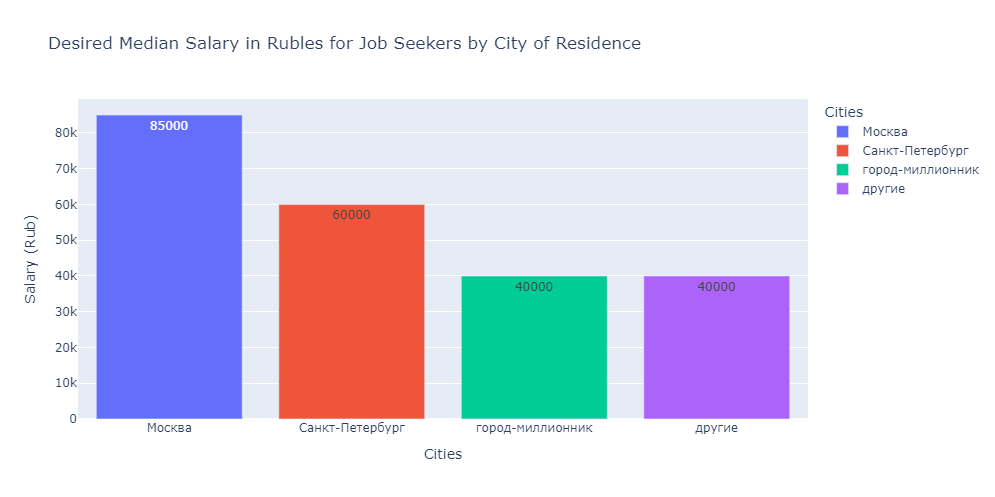

From the obtained chart, we can conclude that **job seekers looking for work in `Москва` ("Moscow") aim for the highest salaries**. Next are job seekers from `Санкт-Петербург` ("Saint Petersburg"). **There is no difference in the median desired salary levels between job seekers living in `город-миллионник` ("million-plus cities") and `другие` ("other") smaller cities**. Regarding whether the **`Город`** ("City") feature is necessary for salary prediction, **the answer is yes, as we observe variations in desired salary sizes**. However, it might be worth combining `город-миллионник` ("million-plus cities") and `другие` ("other") categories, as there is little difference between them.

Post-build a **multi-level bar chart** showing the dependence of the median salary on the features "Readiness for Relocation" and "Readiness for Business Trips". Analyze the chart by comparing salary levels across categories.

In [ ]:
# Build a multi-level bar chart showing the dependence of the median salary on the features "Readiness for Relocation", "Readiness for Business Trips" 

availability_data = hh_data.groupby(['Готовность к переезду', 'Готовность к командировкам'], as_index=False)['ЗП (руб)'].median().round()

fig = px.bar(
    availability_data,
    x='Готовность к переезду',
    y='ЗП (руб)',
    color='Готовность к командировкам',
    barmode='group',
    text = 'ЗП (руб)',
    orientation='v',
    height=500, 
    width=1000, 
    title='Median Salary in Rubles for Job Seekers by Relocation and Business Trip Availability',
    labels={
        'Готовность к переезду':'Readiness for Relocation',
        'ЗП (руб)': 'Salary (Rub)',
        'Готовность к командировкам' :'Readiness for Business Trips'
    }
    
)

fig.show();

#fig.write_html("plotly/availability_data.html")

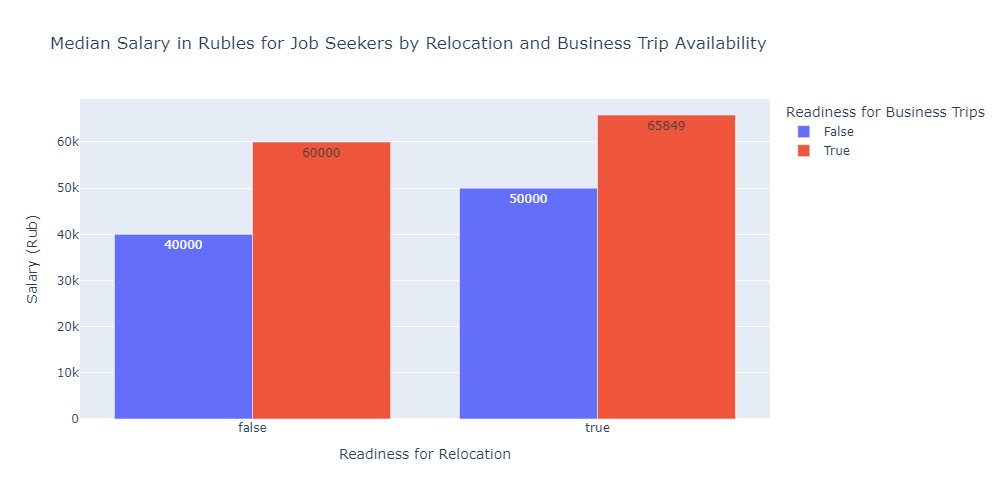

Job seekers **ready for business trips indicate higher desired salaries**. **The highest median desired salary is among job seekers ready for both business trips and relocation**. It is also worth noting that **job seekers not ready for business trips but ready for relocation have a higher median desired salary** compared to those who indicate they are not ready for either.

Post-build a pivot table illustrating the dependence of the **median** desired salary on age and education. Build a **heatmap** based on the obtained pivot table. Analyze the heatmap by comparing indicators within groups.

In [ ]:
# Build a heatmap showing the dependence of the median salary on the features "Education" and "Age"
# Use a heatmap from the Plotly Express library

# Convert the necessary data into a pivot table format

age_edu_pivot = hh_data.pivot_table(
    values='ЗП (руб)',
    index='Образование',
    columns='Возраст',
    aggfunc='median'
)

# Build a heatmap

fig = px.imshow(
    age_edu_pivot,
    title='Dependence of Median Desired Salary on Age and Education'
)

fig.show();

#fig.write_html("plotly/age_edu_pivot.html")

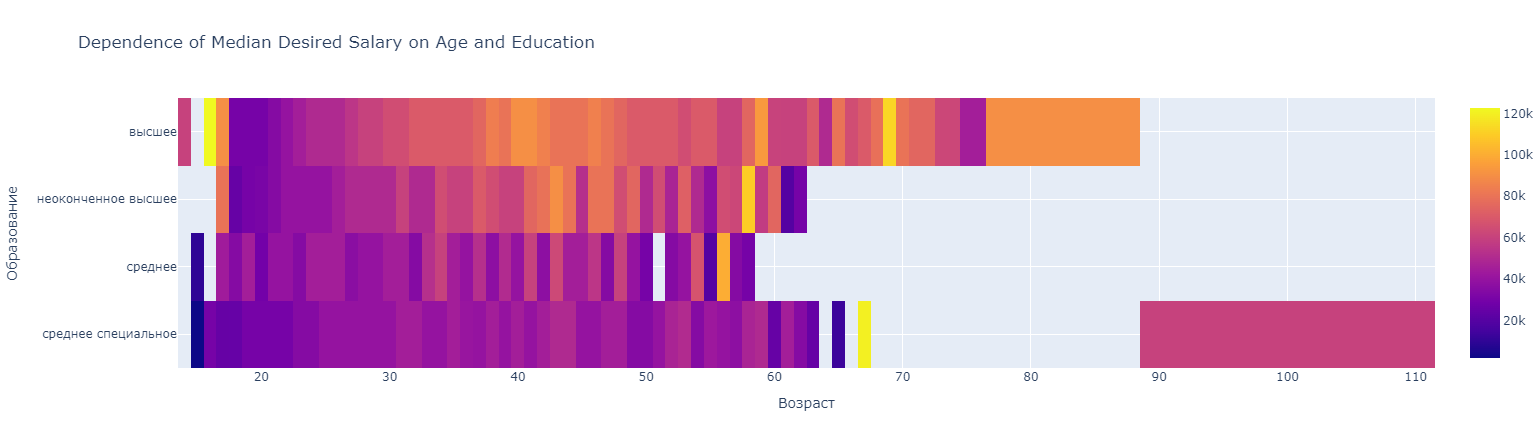

From this heatmap, the following conclusions can be drawn:

* Job seekers with `высшее` ("higher") education have anomalous data, such as: **high median desired salary values at ages under 18 and around 70**, **the presence of job seekers under 18 with higher education**, which is almost impossible. Overall, **the median salary level increases with age, possibly with experience**.  
* Job seekers with `неоконченное высшее` ("incomplete higher") education also have **a normal distribution of desired salary and age**, except for a case at age 17.  
* Job seekers with `среднее` ("secondary") education, as we already know, have **the lowest median desired salary level**.  
* In the group of job seekers with `среднее специальное` ("secondary special") education, there are also **anomalous outliers - the presence of job seekers aged 90 and above**, as well as an anomalously high salary value at age 67. Otherwise, like the `среднее` ("secondary") education group, **we observe the lowest values among the four groups, distributed fairly evenly**.

Post-build a **scatter plot** showing the dependence of work experience on age. Convert work experience from months to years to ensure the features are on the same scale. Add a line passing through the points (0, 0) and (100, 100) to the plot. This line corresponds to values where work experience equals the job seeker's age. Points lying on or above this line are anomalies in our data (work experience is greater than or equal to the job seeker's age).

In [ ]:
# Build a scatter plot showing the dependence of work experience on age  
# Use a scatter plot from the Plotly Express library

# Create a new feature "Work Experience (years)" in our dataset

hh_data['Опыт работы (год)'] = hh_data['Опыт работы (месяц)'] / 12

# создаем график
fig = px.scatter(
    hh_data,
    x='Возраст',
    y='Опыт работы (год)',
    title='Dependence of Work Experience on Age',
    labels={
        'Возраст':'Age',
        'Опыт работы (год)':'work experience'
    }
)

# Create the line

fig.add_shape(
    type='line',
    x0=0, y0=0,
    x1=100, y1=100,
    line=dict(color='Red', dash='dash')
)

fig.show();

#fig.write_html("plotly/age_exp_data.html")

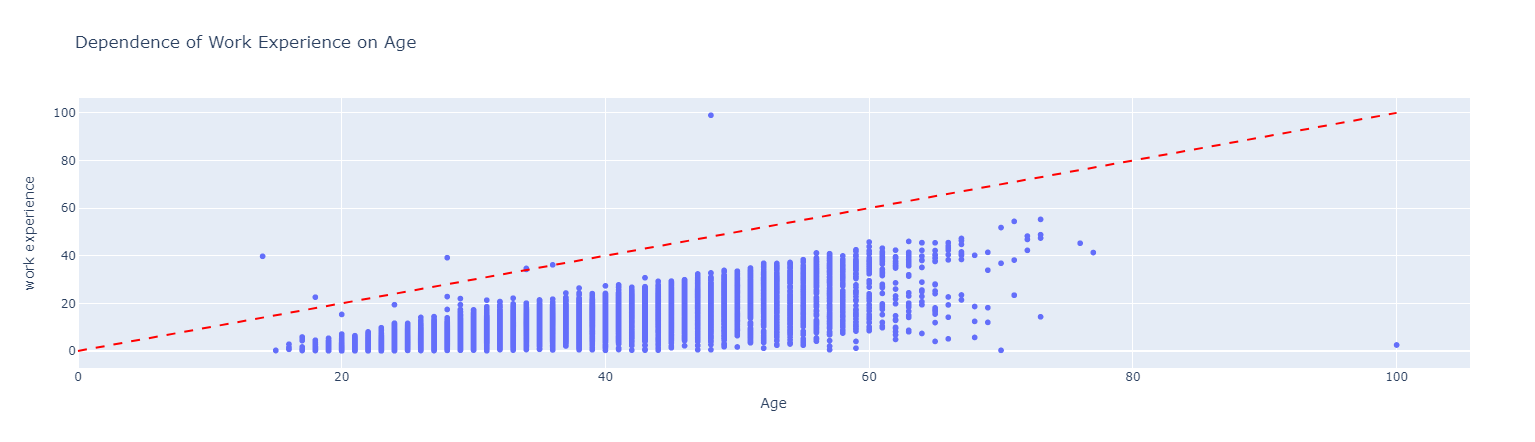

From this plot, a **normal dependence is evident: as age increases, job seekers accumulate more maximum experience**, with dispersion occurring only after reaching retirement age. There are also **anomalous values, such as work experience exceeding age, and one value for an age of 100 years with 2.5 years of experience looks suspicious**.

In [ ]:
# Build a line chart showing the activity of job seekers on the HeadHunter portal by desired employment type  
# Use a line chart from the Plotly Express library

line_data = hh_data.groupby('Обновление резюме', as_index=False).sum()

fig = px.line(
    data_frame=line_data, 
    x='Обновление резюме', 
    y=['полная занятость', 'частичная занятость', 'проектная работа', 'стажировка', 'волонтерство'], 
    height=500, 
    width=1000, 
    title='Resume Updates on the HeadHunter Website by Time and Employment Type',  
    labels={  
        'Обновление резюме': 'Date',  
        'value': 'Number of Job Seekers',  
        'variable': 'Employment Type'  
    }
)

fig.show();

#fig.write_html("plotly/line_employment.html")

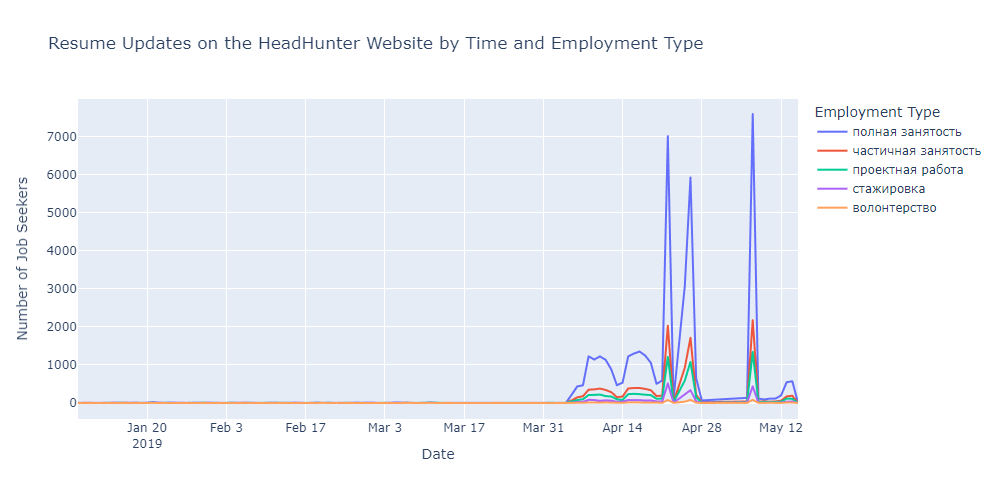

This chart shows how the resume database was updated over time and by data type. It is evident that the majority of job seekers are looking for `полная занятость` ("full-time employment"). Also interesting are three high outliers on April 22, April 26, and May 7. Perhaps the dates were generated manually. In the long term, we can observe the distribution over time for different features and track when job search spikes occur.

In [ ]:
# Build a multi-level bar chart showing the dependence of the median desired salary on the job seeker's gender and city of residence  
# Use a bar chart from the Plotly Express library

gender_data = hh_data[hh_data['ЗП (руб)'] < 1000000].groupby(['Пол', 'Город'], as_index=False)['ЗП (руб)'].median()

fig = px.bar(
    gender_data,
    x='Пол',
    y='ЗП (руб)',
    color='Город',
    barmode='group',
    text = 'ЗП (руб)',
    orientation='v',
    height=500, 
    width=1000, 
    title='Median Salary in Rubles for Job Seekers by Gender',
    labels={  
        'Пол': 'Gender',  
        'ЗП (руб)': 'Salary (Rub)',  
        'Город': 'Cities'  
    }
)

fig.show();

#fig.write_html("plotly/gender_data.html")

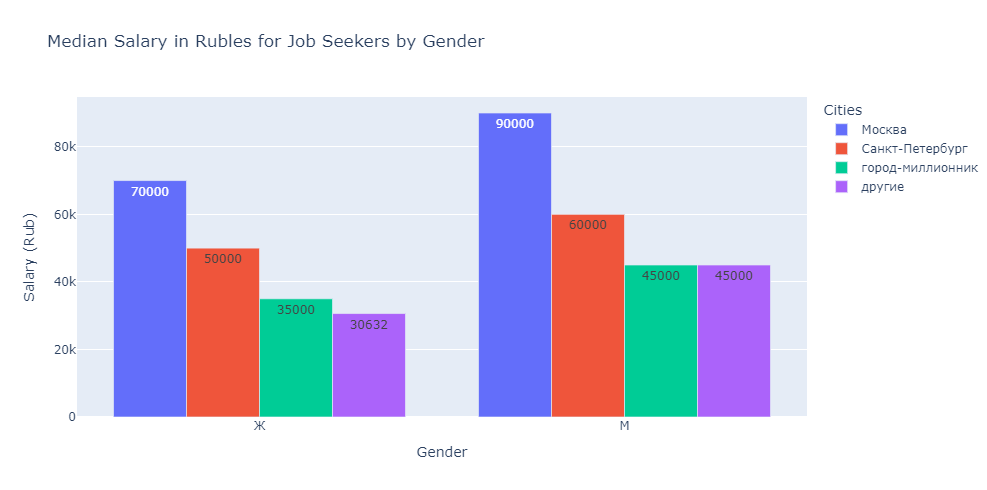

A fairly simple chart, from which we see that **the median desired salary for men is higher than for women**. Additionally, by breaking down the distribution by cities, we can notice that the largest difference is observed in `Москва` ("Moscow") and `другие` ("other") cities, while **in `Санкт-Петербург` ("Saint Petersburg") and `город-миллионник` ("million-plus cities"), the difference does not exceed 10,000 rubles**.

## 4. Data Cleaning

Finally, clean our data of duplicates, handle missing values, and address all outliers identified earlier during data analysis.

In [61]:
# Find and clean the dataset of complete duplicates

dupl_columns = list(hh_data.columns)

dubl_mask = hh_data.duplicated(subset=dupl_columns)
hh_data_duplicates = hh_data[dubl_mask]

hh_data = hh_data.drop_duplicates(subset=dupl_columns)

In [62]:
# Display information about the number of missing values in columns

cols_with_nan = hh_data.isnull().sum().sort_values(ascending=False)
cols_with_nan 

Опыт работы (год)                  168
Опыт работы (месяц)                168
Последняя/нынешняя должность         2
Последнее/нынешнее место работы      1
проектная работа                     0
ЗП (руб)                             0
вахтовый метод                       0
удаленная работа                     0
гибкий график                        0
сменный график                       0
полный день                          0
волонтерство                         0
стажировка                           0
Ищет работу на должность:            0
частичная занятость                  0
Готовность к командировкам           0
Готовность к переезду                0
Город                                0
Возраст                              0
Пол                                  0
Образование                          0
Авто                                 0
Обновление резюме                    0
полная занятость                     0
dtype: int64

We have missing values in three columns: **`Опыт работы (месяц)`** ("Work Experience (months)"), **`Последнее/нынешнее место работы`** ("Last/Current Workplace"), and **`Последняя/нынешняя должность`** ("Last/Current Position"). Proceed as follows: delete rows where there are missing values in the columns with workplace and position. Fill missing values in the **`Опыт работы (месяц)`** ("Work Experience (months)") column with the **median** value.

In [63]:
# Fill missing values in the "Work Experience (months)" feature

values = {
    'Опыт работы (месяц)': hh_data['Опыт работы (месяц)'].median()
}

hh_data = hh_data.fillna(values)

# Recalculate the "Work Experience (years)" feature for further work and delete remaining rows with missing values

hh_data['Опыт работы (год)'] = hh_data['Опыт работы (месяц)'] / 12
hh_data = hh_data.dropna(how='any', axis=0)

We have reached outlier elimination. First, clean the data manually. Delete resumes where the indicated salary is either above 1 million rubles or below 1,000 rubles.

In [64]:
# Find and delete outliers in the desired "Salary (Rub)"

salary_mask1 = hh_data[(hh_data['ЗП (руб)'] > 1000000) | (hh_data['ЗП (руб)'] < 1000)]
hh_data = hh_data.drop(salary_mask1.index, axis=0)

During exploratory analysis, we identified resumes where **work experience in years exceeded the job seeker's age**. Find such resumes and delete them from the data.


In [65]:
# Find and delete outliers in "Work Experience" feature

exp_age_mask = hh_data[hh_data['Опыт работы (год)'] > hh_data['Возраст']]
hh_data = hh_data.drop(exp_age_mask.index, axis=0)

As a result of the analysis, we identified potential outliers in the **`Возраст`** ("Age") feature. These were resumes of individuals of excessively advanced age for job searching. Try building the distribution of the feature in a **logarithmic scale**. Add lines to the plot showing the **mean and the boundaries of the three-sigma interval**. As a reminder, this can be done using the `axvline` method. For example, the line for the mean would look like:

`histplot.axvline(log_age.mean(), color='k', lw=2)`

In which direction is the logarithmic distribution asymmetric? Write about this in the comment to the plot.  
Find outliers using the z-score method and delete them from the data, using the logarithmic scale. Let's make a **one-sigma relaxation** (use 4 sigmas) to the **right side**.

In [66]:
# Find outliers in the "Age" feature using the three-sigma method, with a relaxation to 4 sigmas to the right

# Create a function to find outliers using the three-sigma method

def outliers_z_score_mod(data, feature, left=3, right=3, log_scale=False):
    """Function to find outliers using the three-sigma method

    Args:
        data (DataFrame): Dataset
        feature (str): Feature to analyze
        left (int, optional): Number of sigmas to the left. Defaults to 3.
        right (int, optional): Number of sigmas to the right. Defaults to 3.
        log_scale (bool, optional): Use logarithmic scaling. Defaults to False.

    Returns:
        DataFrame: Slice of the dataset with potential outliers and the cleaned dataset
    """
    
    if log_scale:
        x = np.log(data[feature])
    else:
        x = data[feature]
    mu = x.mean()
    sigma = x.std()
    lower_bound = mu - left * sigma
    upper_bound = mu + right * sigma
    outliers = data[(x < lower_bound) | (x > upper_bound)]
    cleaned = data[(x >= lower_bound) & (x <= upper_bound)]
    return outliers, cleaned

# Apply the function to the "Age" feature and display information about the number of outliers

outliers, cleaned = outliers_z_score_mod(hh_data, 'Возраст', 3,4, log_scale=True)
print(f'Number of outliers by the z-score method: {outliers.shape[0]}')  
print(f'Resulting number of records: {cleaned.shape[0]}')

Number of outliers by the z-score method: 3
Resulting number of records: 44482


In [67]:
# Display the ages that fell into the outlier zone

outliers['Возраст'].value_counts()

Возраст
15     2
100    1
Name: count, dtype: int64

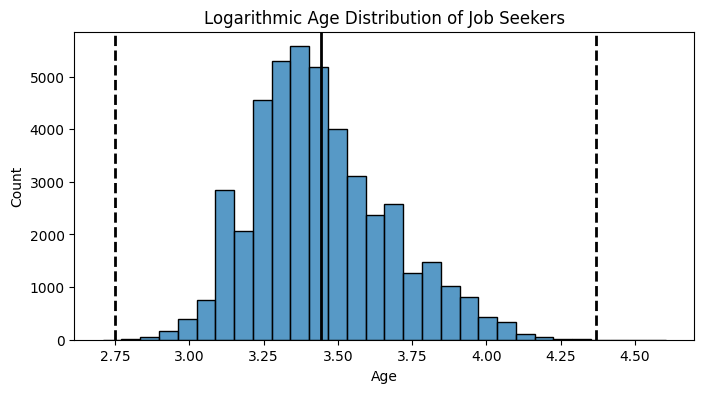

In [68]:
# Build a logarithmic distribution plot for the "Age" feature, with a 4-sigma relaxation to the right

fig, ax = plt.subplots(1,1,figsize=(8,4))
log_age = np.log(hh_data['Возраст'])
histplot = sns.histplot(log_age, bins=30, ax=ax)
histplot.axvline(log_age.mean(), color='k',lw=2)
histplot.axvline(log_age.mean() + 4 * log_age.std(), color='k', ls='--', lw=2)
histplot.axvline(log_age.mean() - 3 * log_age.std(), color='k', ls='--', lw=2)
histplot.set_title('Logarithmic Age Distribution of Job Seekers')
histplot.set_xlabel('Age');

The distribution **resembles a normal one**, **with the logarithmic distribution asymmetrically skewed to the right**, but not significantly. **The number of outliers with a 4-sigma relaxation to the right is small - only 3 people**, one at age 100 and two at age 15.